In [1]:
import os

print(os.getcwd())


c:\Users\admin\Desktop\10-academy\fintech-review-analytics


In [2]:
print(os.listdir())

['.git', '.github', '.gitignore', 'data', 'notebooks', 'README.md', 'requirements.txt', 'scripts', 'src', 'task2_sentiment_analysis.ipynb', 'tests', 'venv']


In [3]:
import pandas as pd

df = pd.read_csv("data/raw/bank_reviews.csv")

df.head()

,review,rating,date,bank,source
0,thanks for you 😘,5,2026-05-16,CBE,Google Play
1,it's okay,4,2026-05-16,CBE,Google Play
2,It's not allowing me to transfer money.,2,2026-05-15,CBE,Google Play
3,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play
4,wow,4,2026-05-14,CBE,Google Play


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  913 non-null    str  
 1   rating  913 non-null    int64
 2   date    913 non-null    str  
 3   bank    913 non-null    str  
 4   source  913 non-null    str  
dtypes: int64(1), str(4)
memory usage: 35.8 KB


In [5]:
df.columns

Index(['review', 'rating', 'date', 'bank', 'source'], dtype='str')

In [6]:
df = df.dropna(subset=['review'])

df = df[df['review'].str.strip() != ""]

print(df.shape)

(913, 5)


In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [8]:
import pandas as pd

df = pd.read_csv("data/raw/bank_reviews.csv")

df.head()

,review,rating,date,bank,source
0,thanks for you 😘,5,2026-05-16,CBE,Google Play
1,it's okay,4,2026-05-16,CBE,Google Play
2,It's not allowing me to transfer money.,2,2026-05-15,CBE,Google Play
3,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play
4,wow,4,2026-05-14,CBE,Google Play


In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

text = df['review'].iloc[0]

score = analyzer.polarity_scores(text)

print(score)

{'neg': 0.0, 'neu': 0.467, 'pos': 0.533, 'compound': 0.6908}


In [10]:
def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    compound = score['compound']

    if compound >= 0.05:
        return "positive", compound
    elif compound <= -0.05:
        return "negative", compound
    else:
        return "neutral", compound

In [11]:
df[['sentiment_label', 'sentiment_score']] = df['review'].apply(
    lambda x: pd.Series(vader_sentiment(x))
)

In [12]:
df[['review', 'sentiment_label', 'sentiment_score']].head()

,review,sentiment_label,sentiment_score
0,thanks for you 😘,positive,0.6908
1,it's okay,positive,0.2263
2,It's not allowing me to transfer money.,neutral,0.0000
3,IT'S NOT WORK ON HUAWEI DEVICES,neutral,0.0000
4,wow,positive,0.5859


In [13]:
df['sentiment_label'].value_counts()

sentiment_label
positive    481
neutral     270
negative    162
Name: count, dtype: int64

In [14]:
bank_sentiment = df.groupby('bank')['sentiment_score'].mean()

print(bank_sentiment)

bank
BOA       0.109527
CBE       0.240255
Dashen    0.264604
Name: sentiment_score, dtype: float64


In [15]:
rating_sentiment = df.groupby('rating')['sentiment_score'].mean()

print(rating_sentiment)

rating
1   -0.167253
2    0.016234
3    0.083468
4    0.251490
5    0.383836
Name: sentiment_score, dtype: float64


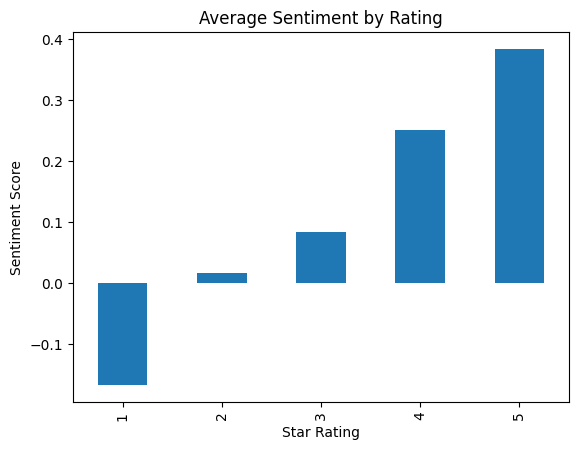

In [16]:
import matplotlib.pyplot as plt

rating_sentiment.plot(kind='bar')

plt.title("Average Sentiment by Rating")
plt.xlabel("Star Rating")
plt.ylabel("Sentiment Score")

plt.show()

In [17]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [18]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [19]:
df['clean_review'] = df['review'].apply(clean_text)

In [20]:
df[['review', 'clean_review']].head()

,review,clean_review
0,thanks for you 😘,thanks
1,it's okay,okay
2,It's not allowing me to transfer money.,allowing transfer money
3,IT'S NOT WORK ON HUAWEI DEVICES,work huawei devices
4,wow,wow


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['clean_review'])

keywords = vectorizer.get_feature_names_out()

print(keywords[:50])

['able' 'able switch' 'able transfer' 'able use' 'abroad' 'abroad enter'
 'absiniya' 'abyssinia' 'access' 'access balance' 'access essential'
 'access money' 'account' 'account balance' 'accounts' 'accurately'
 'activate' 'activated' 'activation' 'active' 'activities' 'actually'
 'added' 'adding' 'addition' 'address' 'affecting' 'agent' 'ago' 'ahead'
 'airtime' 'allowed' 'almost' 'alot' 'also' 'altogether' 'always'
 'always one' 'amaizing' 'amazing' 'amazing app' 'amazing service' 'amole'
 'amole far' 'among' 'amount' 'android' 'annoying' 'another' 'anyone']


In [22]:
def assign_theme(text):

    text = text.lower()

    if any(word in text for word in ['login', 'password', 'signin', 'access']):
        return "Account Access Issues"

    elif any(word in text for word in ['transfer', 'transaction', 'payment']):
        return "Transaction Performance"

    elif any(word in text for word in ['support', 'service', 'help']):
        return "Customer Support"

    elif any(word in text for word in ['ui', 'design', 'interface', 'app']):
        return "UI & Design"

    elif any(word in text for word in ['feature', 'update', 'option']):
        return "Feature Requests"

    else:
        return "Other"

In [23]:
df['identified_theme'] = df['clean_review'].apply(assign_theme)

In [24]:
df['identified_theme'].value_counts()

identified_theme
Other                      438
UI & Design                319
Transaction Performance     64
Customer Support            40
Account Access Issues       28
Feature Requests            24
Name: count, dtype: int64

In [25]:
df.groupby(['bank', 'identified_theme']).size()

bank    identified_theme       
BOA     Account Access Issues        9
        Customer Support            10
        Feature Requests             5
        Other                      155
        Transaction Performance     12
        UI & Design                117
CBE     Account Access Issues        7
        Customer Support            18
        Feature Requests             8
        Other                      156
        Transaction Performance     26
        UI & Design                 81
Dashen  Account Access Issues       12
        Customer Support            12
        Feature Requests            11
        Other                      127
        Transaction Performance     26
        UI & Design                121
dtype: int64

In [26]:
df.to_csv("task2_results.csv", index=False)

In [27]:
df.columns

Index(['review', 'rating', 'date', 'bank', 'source', 'sentiment_label',
       'sentiment_score', 'clean_review', 'identified_theme'],
      dtype='str')

VADER was selected because it is lightweight, fast, and effective for
short customer reviews. It provides polarity scores without requiring
large transformer model downloads, making it suitable for efficient
sentiment analysis on banking app reviews.

Themes were created by grouping recurring TF-IDF keywords into
business-relevant categories.

Examples:
- login, password, access → Account Access Issues
- transfer, payment → Transaction Performance
- support, help → Customer Support